# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


pada project ini saya membuat "Tech Stack Tagger". Dataset yang di ambil adalah dari kaggle dengan link berikut : https://www.kaggle.com/datasets/stackoverflow/stacksample

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
!pip install -q kaggle pandas numpy matplotlib seaborn nltk beautifulsoup4 scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import pickle
from wordcloud import WordCloud
import os
import warnings
from bs4 import XMLParsedAsHTMLWarning
import shutil
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d stackoverflow/stacksample --unzip -p stacksample_raw

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stacksample
License(s): other
100% 1.10G/1.11G [00:16<00:00, 227MB/s]
100% 1.11G/1.11G [00:16<00:00, 70.7MB/s]


In [3]:
import pandas as pd

df_questions = pd.read_csv('stacksample_raw/Questions.csv', encoding='latin-1', nrows=50000)
df_tags = pd.read_csv('stacksample_raw/Tags.csv', encoding='latin-1')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Menggabungkan Tags berdasarkan ID Pertanyaan
df_tags['Tag'] = df_tags['Tag'].astype(str)
tags_grouped = df_tags.groupby('Id')['Tag'].apply(list).reset_index()

In [5]:
# Merge dengan Data Pertanyaan
df_final = pd.merge(df_questions, tags_grouped, on='Id', how='inner')
display(df_final.head())

,Id,OwnerUserId,CreationDate,ClosedDate,Score,Title,Body,Tag
0,80,26.0,2008-08-01T13:57:07Z,NaN,26,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,"[flex, actionscript-3, air]"
1,90,58.0,2008-08-01T14:41:24Z,2012-12-26T03:45:49Z,144,Good branching and merging tutorials for Torto...,<p>Are there any really good tutorials explain...,"[svn, tortoisesvn, branch, branching-and-merging]"
2,120,83.0,2008-08-01T15:50:08Z,NaN,21,ASP.NET Site Maps,<p>Has anyone got experience creating <strong>...,"[sql, asp.net, sitemap]"
3,180,2089740.0,2008-08-01T18:42:19Z,NaN,53,Function for creating color wheels,<p>This is something I've pseudo-solved many t...,"[algorithm, language-agnostic, colors, color-s..."
4,260,91.0,2008-08-01T23:22:08Z,NaN,49,Adding scripting functionality to .NET applica...,<p>I have a little game written in C#. It uses...,"[c#, .net, scripting, compiler-construction]"


In [6]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            50000 non-null  int64  
 1   OwnerUserId   45870 non-null  float64
 2   CreationDate  50000 non-null  object 
 3   ClosedDate    1895 non-null   object 
 4   Score         50000 non-null  int64  
 5   Title         50000 non-null  object 
 6   Body          50000 non-null  object 
 7   Tag           50000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.1+ MB


In [7]:
# Cek Missing Values
df_final.isnull().sum()

,0
Id,0
OwnerUserId,4130
CreationDate,0
ClosedDate,48105
Score,0
Title,0
Body,0
Tag,0


In [8]:
duplicate_count = df_final.duplicated(subset=['Title', 'Body']).sum()
duplicate_count

np.int64(0)

In [9]:
# Distribusi Tag
all_raw_tags = [tag for tags in df_final['Tag'] for tag in tags]
raw_tag_counts = pd.Series(all_raw_tags).value_counts()

print(f"Total Unique Tags: {len(raw_tag_counts)}")
print("5 Tag Teratas:")
print(raw_tag_counts.head(5))
print("\n5 Tag Terbawah:")
print(raw_tag_counts.tail(5))

Total Unique Tags: 9778
5 Tag Teratas:
c#         6370
java       3584
.net       3420
php        3026
asp.net    2880
Name: count, dtype: int64

5 Tag Terbawah:
jqgrid-asp.net           1
branching-and-merging    1
binaries                 1
gestures                 1
dll-injection            1
Name: count, dtype: int64


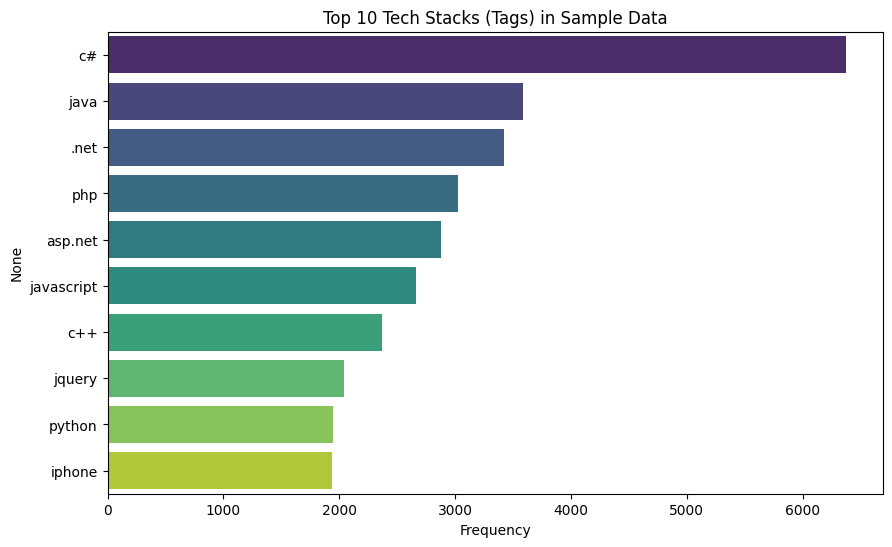

In [10]:
# Visualisasi Top 10 Tags Terpopuler
all_tags = [tag for tags in df_final['Tag'] for tag in tags]
tag_counts = pd.Series(all_tags).value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.values, y=tag_counts.index, hue=tag_counts.index, legend=False, palette='viridis')
plt.title('Top 10 Tech Stacks (Tags) in Sample Data')
plt.xlabel('Frequency')
plt.show()

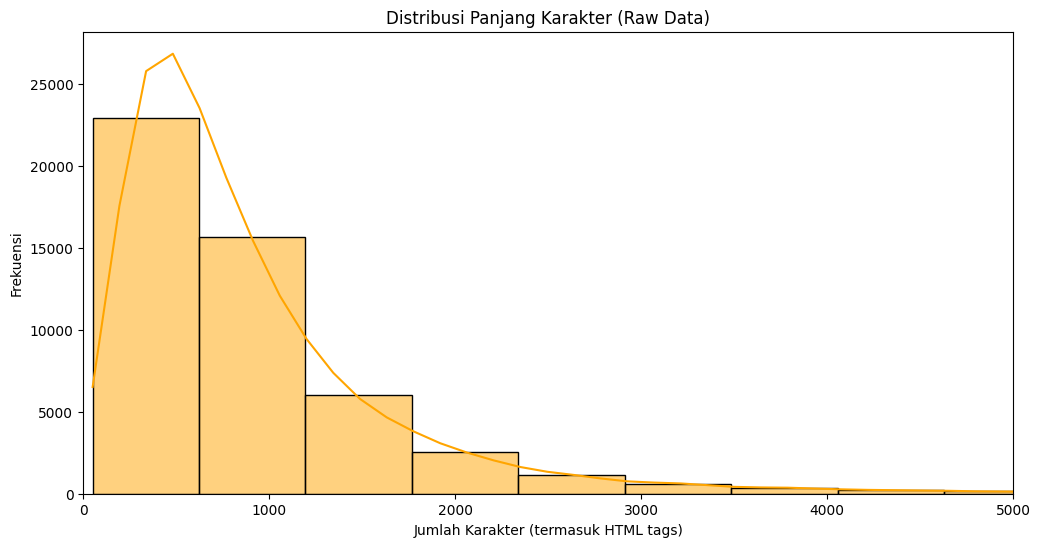

Rata-rata panjang karakter mentah: 949 karakter


In [11]:
# panjang karakter
df_final['raw_char_length'] = (df_final['Title'] + " " + df_final['Body']).astype(str).apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(df_final['raw_char_length'], bins=50, kde=True, color='orange')
plt.title('Distribusi Panjang Karakter (Raw Data)')
plt.xlabel('Jumlah Karakter (termasuk HTML tags)')
plt.ylabel('Frekuensi')
plt.xlim(0, 5000)
plt.show()

print(f"Rata-rata panjang karakter mentah: {df_final['raw_char_length'].mean():.0f} karakter")

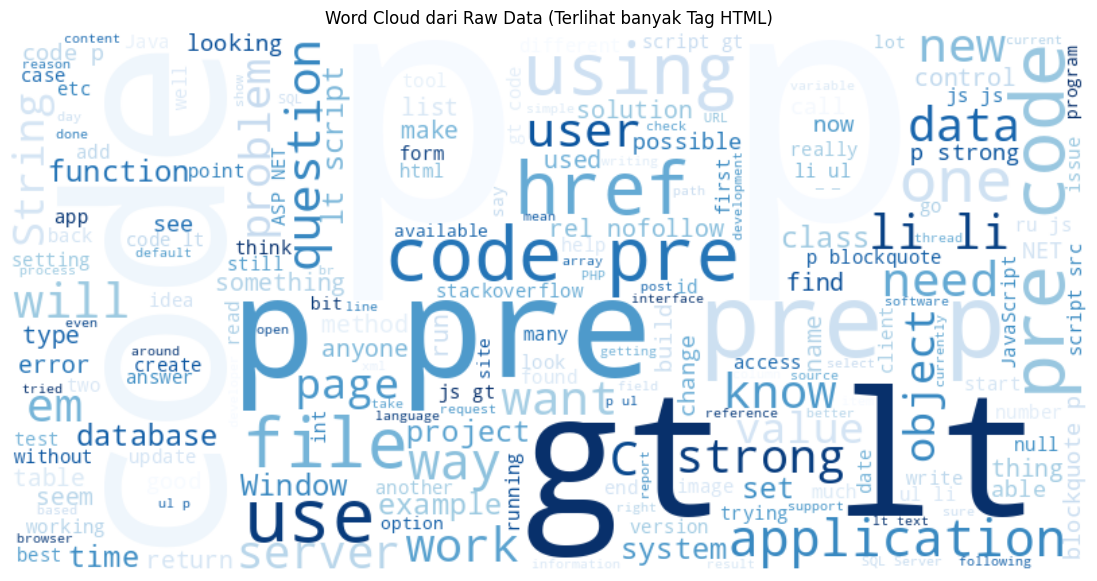

In [12]:
sample_text = " ".join(df_final['Body'].astype(str).iloc[:1000])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(sample_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Raw Data (Terlihat banyak Tag HTML)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z\s<>]', '', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    words = text.split()
    clean_words = []
    for w in words:
        if w not in stop_words and len(w) > 2:
            clean_words.append(lemmatizer.lemmatize(w))

    return " ".join(words)

In [14]:
df_final['text_raw'] = df_final['Title'] + " " + df_final['Body']
df_final = df_final.dropna(subset=['text_raw'])

In [15]:
df_final = df_final.drop_duplicates(subset=['text_raw'])

In [16]:
df_final['text_clean'] = df_final['text_raw'].apply(clean_text)

In [17]:
df_final = df_final[df_final['text_clean'].str.strip().astype(bool)]

In [18]:
df_final['word_count'] = df_final['text_clean'].apply(lambda x: len(x.split()))
df_final = df_final[df_final['word_count'] >= 5]

In [19]:
cols_to_drop = [
    'Id', 'OwnerUserId', 'CreationDate', 'ClosedDate', 'Score',
    'Title', 'Body', 'raw_char_length', 'text_raw', 'word_count'
]

df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [20]:
df_final.head()

,Tag,text_clean
0,"[flex, actionscript-3, air]",sqlstatementexecute multiple queries in one st...
1,"[svn, tortoisesvn, branch, branching-and-merging]",good branching and merging tutorials for torto...
2,"[sql, asp.net, sitemap]",aspnet site maps has anyone got experience cre...
3,"[algorithm, language-agnostic, colors, color-s...",function for creating color wheels this is som...
4,"[c#, .net, scripting, compiler-construction]",adding scripting functionality to net applicat...


## FEATURE ENGINEERING

In [21]:
# FILTER TAGS
all_tags = [tag for tags in df_final['Tag'] for tag in tags]
top_20_tags = pd.Series(all_tags).value_counts().head(20).index.tolist()

def filter_top_tags(tags):
    return [t for t in tags if t in top_20_tags]

df_final['filtered_tags'] = df_final['Tag'].apply(filter_top_tags)

df_final = df_final[df_final['filtered_tags'].str.len() > 0]

In [22]:
# LABEL BINARIZATION
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df_final['filtered_tags'])

print(f"Shape Label (y): {y.shape}")
print(f"Contoh Label Pertama: {y[0]}")
print(f"Kelas (Urutan Tag): {mlb.classes_}")

Shape Label (y): (32819, 20)
Contoh Label Pertama: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
Kelas (Urutan Tag): ['.net' 'asp.net' 'asp.net-mvc' 'c' 'c#' 'c++' 'css' 'html' 'iphone'
 'java' 'javascript' 'jquery' 'mysql' 'objective-c' 'php' 'python'
 'ruby-on-rails' 'sql' 'sql-server' 'wpf']


In [23]:
# TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df_final['text_clean'])

print(f"Shape Features (X): {X.shape}")

Shape Features (X): (32819, 5000)


In [24]:
# SIMPAN DATA & ARTIFACTS (Wajib buat MLOps)
output_folder = 'preprocessing/stacksample_preprocessing'
os.makedirs(output_folder, exist_ok=True)

# Simpan CSV bersih
df_final[['text_clean', 'filtered_tags']].to_csv(f'{output_folder}/clean_data.csv', index=False)

# Simpan TF-IDF dan MLB
with open(f'{output_folder}/tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open(f'{output_folder}/mlb_model.pkl', 'wb') as f:
    pickle.dump(mlb, f)

print(f"\nSUKSES! Data bersih tersimpan di: {output_folder}/clean_data.csv")
print("Artifacts (tfidf & mlb) juga sudah tersimpan.")


SUKSES! Data bersih tersimpan di: preprocessing/stacksample_preprocessing/clean_data.csv
Artifacts (tfidf & mlb) juga sudah tersimpan.


# TAHAP OTOMATISASI (SKILLED)

In [30]:
%%writefile preprocessing/automate_alsyabella.py
import os
import re
import pickle
import warnings
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from bs4 import XMLParsedAsHTMLWarning
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

# KONFIGURASI
SAMPLE_SIZE = 50000
RAW_DATA_PATH = 'stacksample_raw'
OUTPUT_PATH = 'preprocessing/stacksample_preprocessing'

warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)
os.makedirs(OUTPUT_PATH, exist_ok=True)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def load_data():
    if not os.path.exists(f'{RAW_DATA_PATH}/Questions.csv'):
        os.system(f'kaggle datasets download -d stackoverflow/stacksample --unzip -p {RAW_DATA_PATH}')

    df_questions = pd.read_csv(f'{RAW_DATA_PATH}/Questions.csv', encoding='latin-1', nrows=SAMPLE_SIZE + 5000)
    df_tags = pd.read_csv(f'{RAW_DATA_PATH}/Tags.csv', encoding='latin-1')

    df_tags = df_tags[df_tags['Id'].isin(df_questions['Id'])]

    return df_questions, df_tags

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z\s<>]', '', text)
    text = text.lower()
    words = text.split()
    clean_words = []
    for w in words:
        if w not in stop_words and len(w) > 2:
            clean_words.append(lemmatizer.lemmatize(w))

    return " ".join(clean_words)

def process_data(df_questions, df_tags):
    df_tags['Tag'] = df_tags['Tag'].astype(str)
    tags_grouped = df_tags.groupby('Id')['Tag'].apply(list).reset_index()

    df_final = pd.merge(df_questions, tags_grouped, on='Id', how='inner')
    df_final['text_raw'] = df_final['Title'] + " " + df_final['Body']

    df_final = df_final.dropna(subset=['text_raw'])
    df_final = df_final.drop_duplicates(subset=['text_raw'])

    df_final['text_clean'] = df_final['text_raw'].apply(clean_text)

    df_final = df_final[df_final['text_clean'].str.strip().astype(bool)]

    df_final['word_count'] = df_final['text_clean'].apply(lambda x: len(x.split()))
    df_final = df_final[df_final['word_count'] >= 5]

    cols_to_drop = [
    'Id', 'OwnerUserId', 'CreationDate', 'ClosedDate', 'Score',
    'Title', 'Body', 'raw_char_length', 'text_raw', 'word_count']
    df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    df_final = df_final.head(SAMPLE_SIZE)

    return df_final

def save_artifacts(df_final):
    all_tags = [tag for tags in df_final['Tag'] for tag in tags]
    top_tags = pd.Series(all_tags).value_counts().head(20).index.tolist()

    def filter_tags(tags):
        return [t for t in tags if t in top_tags]

    df_final['filtered_tags'] = df_final['Tag'].apply(filter_tags)
    df_final = df_final[df_final['filtered_tags'].str.len() > 0]

    mlb = MultiLabelBinarizer()
    mlb.fit(df_final['filtered_tags'])

    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    tfidf.fit(df_final['text_clean'])

    df_final[['text_clean', 'filtered_tags']].to_csv(f'{OUTPUT_PATH}/clean_data.csv', index=False)

    with open(f'{OUTPUT_PATH}/tfidf_model.pkl', 'wb') as f:
        pickle.dump(tfidf, f)

    with open(f'{OUTPUT_PATH}/mlb_model.pkl', 'wb') as f:
        pickle.dump(mlb, f)

    print("[SUCCESS] Selesai! Script berjalan lancar.")

if __name__ == "__main__":
    questions, tags = load_data()
    final_df = process_data(questions, tags)
    save_artifacts(final_df)

Overwriting preprocessing/automate_alsyabella.py


## Susunan File

In [31]:
ROOT_NAME = "Eksperimen_SML_Alsyabella_Saputra"
DATASET_NAME = "stacksample"

if os.path.exists(ROOT_NAME):
    shutil.rmtree(ROOT_NAME)
os.makedirs(ROOT_NAME)

raw_path = f"{ROOT_NAME}/{DATASET_NAME}_raw"
os.makedirs(raw_path, exist_ok=True)
with open(f"{raw_path}/README.txt", "w") as f:
    f.write("Dataset Raw ada di Kaggle pada link berikut https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fstackoverflow%2Fstacksample . Akan didownload otomatis oleh script.")

prep_path = f"{ROOT_NAME}/preprocessing"
os.makedirs(prep_path, exist_ok=True)

os.path.exists("preprocessing/automate_alsyabella.py")
shutil.copy("preprocessing/automate_alsyabella.py", f"{prep_path}/automate_alsyabella.py")

dest_output = f"{prep_path}/{DATASET_NAME}_preprocessing"
os.makedirs(dest_output, exist_ok=True)
source_output = "preprocessing/stacksample_preprocessing"

files_penting = ['clean_data.csv', 'tfidf_model.pkl', 'mlb_model.pkl']
for fname in files_penting:
    if os.path.exists(f"{source_output}/{fname}"):
        shutil.copy(f"{source_output}/{fname}", f"{dest_output}/{fname}")

zip_name = f"{ROOT_NAME}.zip"
if os.path.exists(zip_name):
    os.remove(zip_name)

os.system(f"zip -r {zip_name} {ROOT_NAME}")
size = os.path.getsize(zip_name) / (1024 * 1024)
print(f"size file : {size:.2f} MB")

size file : 5.68 MB


In [32]:
from google.colab import files
files.download('Eksperimen_SML_Alsyabella_Saputra.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>